<a href="https://colab.research.google.com/github/saeedzainab274-bit/Brain-Tumor-Deep-Learning-project/blob/main/BrainTumor_Project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import os

# Create the directories if they don't exist
os.makedirs(yes_path, exist_ok=True)
os.makedirs(no_path, exist_ok=True)

print(f"Created directory: {yes_path}")
print(f"Created directory: {no_path}")

Created directory: /content/yes
Created directory: /content/no


In [14]:
# Unzip the archive containing the dataset
import zipfile
import os

archive_path = '/content/archive.zip'
extraction_path = '/content/'

if os.path.exists(archive_path):
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"'{archive_path}' extracted to '{extraction_path}'.")
else:
    print(f"Archive file '{archive_path}' not found.")

'/content/archive.zip' extracted to '/content/'.


In [15]:
import shutil
import os

# Define source and destination paths based on common archive structure
source_base_path = '/content/brain_tumor_dataset'
source_yes_folder = os.path.join(source_base_path, 'yes')
source_no_folder = os.path.join(source_base_path, 'no')

# Destination paths are already defined in the kernel from cell xIl0sQvmIyFN
dest_yes_folder = yes_path # /content/yes
dest_no_folder = no_path   # /content/no

def move_files(source_dir, dest_dir):
    if os.path.exists(source_dir):
        print(f"Moving files from '{source_dir}' to '{dest_dir}'...")
        for filename in os.listdir(source_dir):
            source_file_path = os.path.join(source_dir, filename)
            dest_file_path = os.path.join(dest_dir, filename)

            # If the destination file already exists, remove it first to allow overwriting
            if os.path.exists(dest_file_path):
                os.remove(dest_file_path)
                # print(f"Removed existing file: {dest_file_path}") # Optional: for debugging

            shutil.move(source_file_path, dest_dir)
        print(f"Finished moving files from '{source_dir}'.")
        # Clean up the now empty source directory
        os.rmdir(source_dir)
    else:
        print(f"Source directory '{source_dir}' does not exist. Skipping move operation.")

move_files(source_yes_folder, dest_yes_folder)
move_files(source_no_folder, dest_no_folder)

# Clean up the base extracted directory if it's empty
if os.path.exists(source_base_path) and not os.listdir(source_base_path):
    os.rmdir(source_base_path)
    print(f"Removed empty base directory '{source_base_path}'.")


Moving files from '/content/brain_tumor_dataset/yes' to '/content/yes'...
Finished moving files from '/content/brain_tumor_dataset/yes'.
Moving files from '/content/brain_tumor_dataset/no' to '/content/no'...
Finished moving files from '/content/brain_tumor_dataset/no'.
Removed empty base directory '/content/brain_tumor_dataset'.


**Task 1.2: Data Validation.**

In [16]:
import os

yes_path = "/content/yes"
no_path = "/content/no"

print("Tumor Images:", len(os.listdir(yes_path)))
print("No Tumor Images:", len(os.listdir(no_path)))

total = len(os.listdir(yes_path)) + len(os.listdir(no_path))
print("Total Images:", total)


Tumor Images: 155
No Tumor Images: 98
Total Images: 253


**Check for Corrupted Images**

In [17]:
from PIL import Image
import os

def check_images(folder):
    bad_images = []

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            bad_images.append(img_name)

    return bad_images

bad_yes = check_images("/content/yes")
bad_no = check_images("/content/no")

print("Corrupted Tumor Images:", len(bad_yes))
print("Corrupted No Tumor Images:", len(bad_no))

Corrupted Tumor Images: 0
Corrupted No Tumor Images: 0


**Show Sample Images**

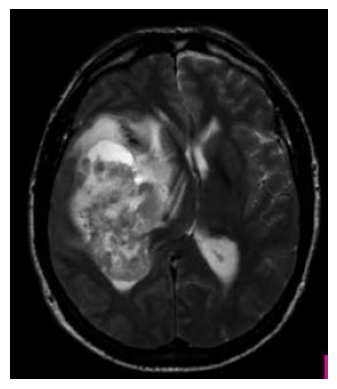

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os

tumor_image = os.listdir("/content/yes")[0]
img = Image.open(f"/content/yes/{tumor_image}")

plt.imshow(img)
plt.axis("off")
plt.show()


**Task 1.3: Preprocessing (Resize + Normalize Images**

**Import Libraries**

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Create Data Generator

In [21]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

**Create Training Data**

In [22]:
train_data = datagen.flow_from_directory(
    "/content",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 216 images belonging to 4 classes.


**Create Validation Data**

In [23]:
val_data = datagen.flow_from_directory(
    "/content",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 37 images belonging to 4 classes.


**Task 1.4 Train/Test Split**



### Fixing the Data Directory Structure

The `ImageDataGenerator` was incorrectly identifying 4 classes because it was scanning the entire `/content` directory, which included `.config` and `sample_data` folders. To ensure binary classification, we will create a new base directory and move only the 'yes' and 'no' image folders into it.

In [36]:
import os
import shutil

# Define the new base directory for brain tumor data
corrected_base_path = '/content/brain_tumor_data'

# Create the new base directory if it doesn't exist
os.makedirs(corrected_base_path, exist_ok=True)

# Define paths for the 'yes' and 'no' folders within the new base directory
corrected_yes_path = os.path.join(corrected_base_path, 'yes')
corrected_no_path = os.path.join(corrected_base_path, 'no')

# Create 'yes' and 'no' subdirectories inside the new base directory
os.makedirs(corrected_yes_path, exist_ok=True)
os.makedirs(corrected_no_path, exist_ok=True)

# Move images from the original '/content/yes' to '/content/brain_tumor_data/yes'
for filename in os.listdir(yes_path):
    shutil.move(os.path.join(yes_path, filename), corrected_yes_path)

# Move images from the original '/content/no' to '/content/brain_tumor_data/no'
for filename in os.listdir(no_path):
    shutil.move(os.path.join(no_path, filename), corrected_no_path)

print(f"Moved images from {yes_path} to {corrected_yes_path}")
print(f"Moved images from {no_path} to {corrected_no_path}")

# Update the global variables to point to the new paths
yes_path = corrected_yes_path
no_path = corrected_no_path

print("Tumor images (new path):", len(os.listdir(yes_path)))
print("No Tumor images (new path):", len(os.listdir(no_path)))

Moved images from /content/yes to /content/brain_tumor_data/yes
Moved images from /content/no to /content/brain_tumor_data/no
Tumor images (new path): 155
No Tumor images (new path): 98


### Re-creating Data Generators with Corrected Paths

Now that the image data is in the correct directory structure (`/content/brain_tumor_data` containing only `yes` and `no` subfolders), we need to re-create the `train_data` and `val_data` generators, pointing them to this new base path.

In [37]:
# Re-create datagen
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

# Re-create train_data pointing to the corrected base path
train_data = datagen.flow_from_directory(
    corrected_base_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Re-create val_data pointing to the corrected base path
val_data = datagen.flow_from_directory(
    corrected_base_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# Print the new class indices to confirm
print("New train_data.class_indices:", train_data.class_indices)

Found 216 images belonging to 2 classes.
Found 37 images belonging to 2 classes.
New train_data.class_indices: {'no': 0, 'yes': 1}


In [38]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


**Visualize Processed Images**

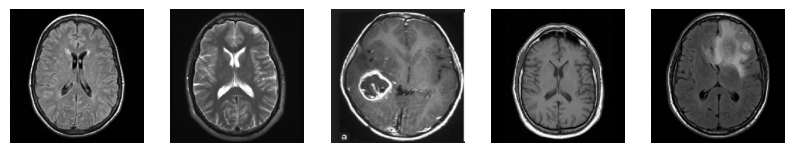

In [39]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

**Model 1: 3-Layer CNN**

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model 1**

In [41]:
history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5880 - loss: 0.8546 - val_accuracy: 0.7838 - val_loss: 0.5125
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7824 - loss: 0.5179 - val_accuracy: 0.7568 - val_loss: 0.5462
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.7824 - loss: 0.4787 - val_accuracy: 0.7568 - val_loss: 0.5095
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8426 - loss: 0.4123 - val_accuracy: 0.7838 - val_loss: 0.5430
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8565 - loss: 0.3552 - val_accuracy: 0.7838 - val_loss: 0.5270
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9028 - loss: 0.2865 - val_accuracy: 0.8378 - val_loss: 0.5980
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8981 - loss: 0.2557 - val_accuracy: 0.8649 - val_loss: 0.4905
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9306 - loss: 0.1730 - val_accuracy: 0.8378 - val_loss: 0.4875
Epoch 9/

**Plot Accuracy and Loss**

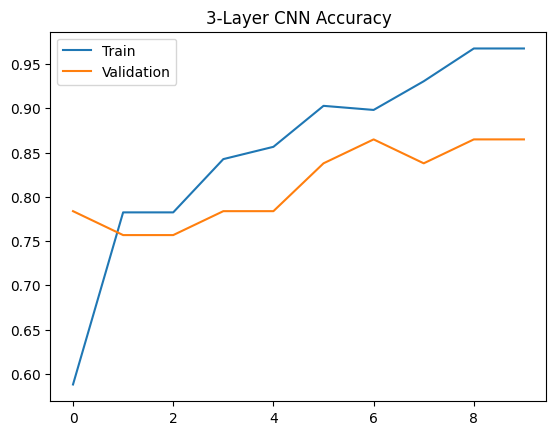

In [43]:
import matplotlib.pyplot as plt

plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('3-Layer CNN Accuracy')
plt.legend(['Train','Validation'])
plt.show()

**Evaluate Model**

In [44]:
loss, accuracy = model3.evaluate(val_data)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.8649 - loss: 0.6471
Accuracy: 0.8648648858070374


# **Model 2: 4-Layer CNN**

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model4 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history4 = model4.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.5787 - loss: 0.7836 - val_accuracy: 0.7297 - val_loss: 0.5655
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.7407 - loss: 0.5536 - val_accuracy: 0.7568 - val_loss: 0.5280
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.7731 - loss: 0.5160 - val_accuracy: 0.7568 - val_loss: 0.5409
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.8056 - loss: 0.4821 - val_accuracy: 0.7568 - val_loss: 0.5772
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8148 - loss: 0.4293 - val_accuracy: 0.7568 - val_loss: 0.5602
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8333 - loss: 0.4027 - val_accuracy: 0.8108 - val_loss: 0.5372
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8380 - loss: 0.3543 - val_accuracy: 0.7568 - val_loss: 0.7337
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.8565 - loss: 0.3632 - val_accuracy: 0.8108 - val_loss: 0.5112
Epoch 9/

In [46]:
loss, accuracy = model4.evaluate(val_data)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.8108 - loss: 0.4941
Accuracy: 0.8108108043670654


# **Model 3: 5-Layer CNN**

In [47]:
model5 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(512,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history5 = model5.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6111 - loss: 0.7022 - val_accuracy: 0.6216 - val_loss: 0.6365
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.6574 - loss: 0.6782 - val_accuracy: 0.7027 - val_loss: 0.6207
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.7037 - loss: 0.5972 - val_accuracy: 0.7838 - val_loss: 0.5075
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.7639 - loss: 0.5372 - val_accuracy: 0.7838 - val_loss: 0.4778
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.7963 - loss: 0.4831 - val_accuracy: 0.7568 - val_loss: 0.5013
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.8148 - loss: 0.4553 - val_accuracy: 0.7838 - val_loss: 0.4860
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.8102 - loss: 0.4349 - val_accuracy: 0.8378 - val_loss: 0.4619
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8565 - loss: 0.3606 - val_accuracy: 0.8378 - val_loss: 0.4641
Epoch 9/

In [49]:
loss, accuracy = model5.evaluate(val_data)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.8108 - loss: 0.4741
Accuracy: 0.8108108043670654


# **Compare All Models**

In [50]:
print("3 Layer CNN Accuracy:")
model3.evaluate(val_data)

print("4 Layer CNN Accuracy:")
model4.evaluate(val_data)

print("5 Layer CNN Accuracy:")
model5.evaluate(val_data)

3 Layer CNN Accuracy:
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.8649 - loss: 0.6471
4 Layer CNN Accuracy:
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.8108 - loss: 0.4941
5 Layer CNN Accuracy:
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.8108 - loss: 0.4741


[0.4741151034832001, 0.8108108043670654]

# **Confusion Matrix (Required)**

In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = model3.predict(val_data)
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(val_data.classes, y_pred[:len(val_data.classes)])

print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step
[[ 3 11]
 [ 6 17]]


# **Precision, Recall, F1 Score (Required)**

In [52]:
print(classification_report(
    val_data.classes,
    y_pred[:len(val_data.classes)]
))

              precision    recall  f1-score   support

           0       0.33      0.21      0.26        14
           1       0.61      0.74      0.67        23

    accuracy                           0.54        37
   macro avg       0.47      0.48      0.46        37
weighted avg       0.50      0.54      0.51        37

